In [1]:
import torch

print(torch.cuda.is_available())

True


In [2]:
import os
import pandas as pd

root_dir = '../dataset/images'
output_csv_path = '../dataset/dataset.csv'

data = []

for dirpath, dirnames, filenames in os.walk(root_dir):
    if dirpath != root_dir:
        label = os.path.basename(dirpath)
        for filename in filenames:
            file_path_full = os.path.normpath(os.path.join(dirpath, filename))
            data.append({'file_path': file_path_full, 'label': label})

df = pd.DataFrame(data)
df = df[df['label'] != '.ipynb_checkpoints']
df.to_csv(output_csv_path, index=False)

In [3]:
import pandas as pd

df = pd.read_csv("../dataset/dataset.csv")

In [4]:
df.head()

,file_path,label
0,"../dataset/images/Apple,Leaf Rust/plant_96067.jpg","Apple,Leaf Rust"
1,"../dataset/images/Apple,Leaf Rust/plant_99354.jpg","Apple,Leaf Rust"
2,"../dataset/images/Apple,Leaf Rust/plant_97379.jpg","Apple,Leaf Rust"
3,"../dataset/images/Apple,Leaf Rust/plant_101192...","Apple,Leaf Rust"
4,"../dataset/images/Apple,Leaf Rust/plant_96701.jpg","Apple,Leaf Rust"


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137000 entries, 0 to 136999
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   file_path  137000 non-null  object
 1   label      137000 non-null  object
dtypes: object(2)
memory usage: 2.1+ MB


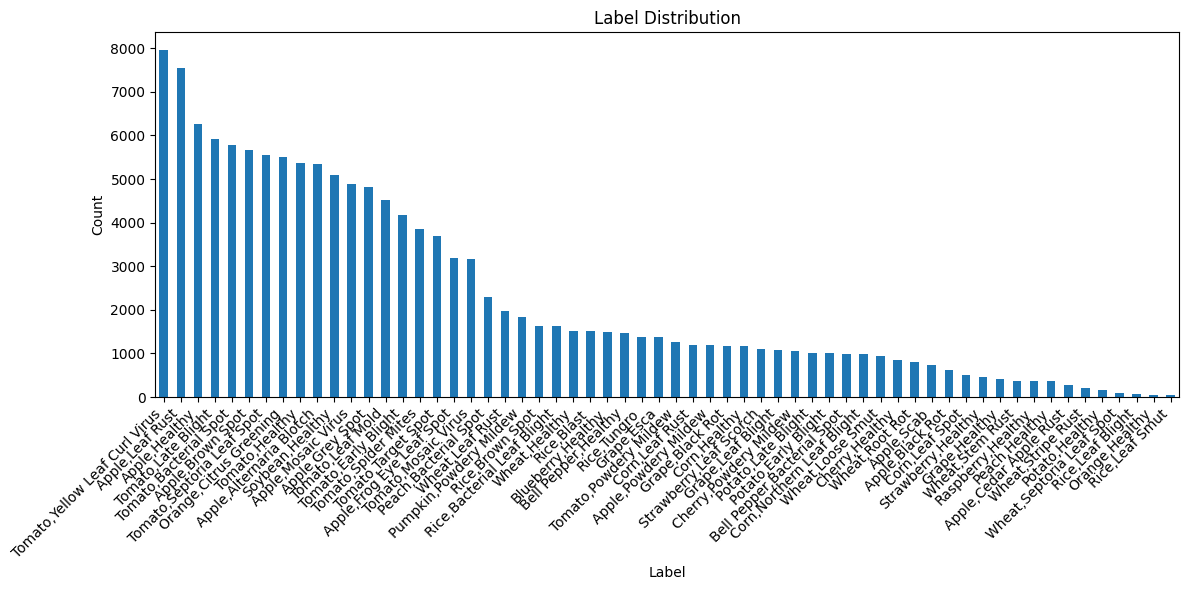

In [6]:
import matplotlib.pyplot as plt

label_counts = df["label"].value_counts()
plt.figure(figsize=(12, 6))
label_counts.plot(kind="bar")
plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [7]:
unique_labels = sorted(df["label"].unique())
class_to_id = {label: i for i, label in enumerate(unique_labels)}
id_to_class = {i: label for label, i in class_to_id.items()}
df["class_id"] = df["label"].map(class_to_id)

In [8]:
len(unique_labels)

60

In [9]:
df.sample(5)

,file_path,label,class_id
101353,"../dataset/images/Bell Pepper,Healthy/plant_12...","Bell Pepper,Healthy",12
111902,"../dataset/images/Apple,Healthy/plant_89478.jpg","Apple,Healthy",6
121591,"../dataset/images/Apple,Alternaria Blotch/plan...","Apple,Alternaria Blotch",0
52837,"../dataset/images/Tomato,Spider Mites/plant_47...","Tomato,Spider Mites",50
1516,"../dataset/images/Apple,Leaf Rust/plant_101342...","Apple,Leaf Rust",7


In [10]:
from sklearn.model_selection import train_test_split

X = df[["file_path", "label"]]
y = df["class_id"]
X_rem, X_test, y_rem, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_rem, y_rem, test_size=(0.15 / 0.90), random_state=42, stratify=y_rem
)

In [11]:
X_train.shape, X_val.shape, X_test.shape

((102750, 2), (20550, 2), (13700, 2))

In [12]:
import os

os.environ["TRANSFORMERS_CACHE"] = "../hf"
os.environ["HF_HOME"] = "../hf"

In [13]:
import evaluate
import numpy as np
import torch
from transformers import (
    Trainer,
    TrainingArguments,
    ViTForImageClassification,
    ViTImageProcessor,
)

MODEL_CHECKPOINT = "google/vit-base-patch16-224"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ViTForImageClassification.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels=len(unique_labels),
    id2label=id_to_class,
    label2id=class_to_id,
    ignore_mismatched_sizes=True,
).to(device)

print(device)

/workspace/MultiModalCropAssistant/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/workspace/MultiModalCropAssistant/env/lib/python3.12/site-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([60]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([60, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be ab

cuda


In [14]:
metric = evaluate.load("f1")


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(
        predictions=predictions, references=labels, average="weighted"
    )

In [ ]:
training_args = TrainingArguments(
    output_dir="./vit_crop",
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32, 
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=250,
    save_strategy="epoch",
    eval_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",  # important
    learning_rate=2e-5,
    fp16=True,
)

In [16]:
processor = ViTImageProcessor.from_pretrained(MODEL_CHECKPOINT)

In [17]:
import torch
from datasets import Dataset
from PIL import Image

train_df = pd.concat([X_train, y_train], axis=1).reset_index(drop=True)
val_df = pd.concat([X_val, y_val], axis=1).reset_index(drop=True)
test_df = pd.concat([X_test, y_test], axis=1).reset_index(drop=True)

train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)


def preprocess_images(examples):
    images = [Image.open(path).convert("RGB") for path in examples["file_path"]]
    inputs = processor(images=images, return_tensors=None)
    inputs["labels"] = examples["class_id"]
    return inputs


train_dataset = train_dataset.map(
    preprocess_images,
    batched=True,
    batch_size=32, 
    remove_columns=["file_path", "label", "class_id"],
)
val_dataset = val_dataset.map(
    preprocess_images,
    batched=True,
    batch_size=32,
    remove_columns=["file_path", "label", "class_id"],
)
test_dataset = test_dataset.map(
    preprocess_images,
    batched=True,
    batch_size=32,
    remove_columns=["file_path", "label", "class_id"],
)

train_dataset.set_format("torch")
val_dataset.set_format("torch")
test_dataset.set_format("torch")




ap: 100%|██████████| 13700/13700 [00:41<00:00, 331.52 examples/s]

In [18]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=processor,
    compute_metrics=compute_metrics,
)

In [35]:
trainer.train()

Epoch,Training Loss,Validation Loss,F1
1,0.018600,0.048646,0.987967
2,0.009000,0.052762,0.988501
3,0.005800,0.048334,0.989110
4,0.005400,0.047897,0.989033
5,0.006400,0.053426,0.989579


TrainOutput(global_step=32110, training_loss=0.01030284149444055, metrics={'train_runtime': 26782.5598, 'train_samples_per_second': 19.182, 'train_steps_per_second': 1.199, 'total_flos': 4.003813082300542e+19, 'train_loss': 0.01030284149444055, 'epoch': 5.0})

In [36]:
results = trainer.evaluate(test_dataset)
results

{'eval_loss': 0.04830734804272652,
 'eval_f1': 0.9890299891338116,
 'eval_runtime': 567.022,
 'eval_samples_per_second': 24.161,
 'eval_steps_per_second': 0.757,
 'epoch': 5.0}

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=-1)
y_true = predictions.label_ids

print(
    classification_report(
        y_true,
        y_pred,
        labels=list(range(len(unique_labels))),
        target_names=unique_labels,
        zero_division=0,
    )
)

                               precision    recall  f1-score   support

      Apple,Alternaria Blotch       0.95      0.96      0.96       534
              Apple,Black Rot       1.00      1.00      1.00        62
             Apple,Brown Spot       0.99      0.98      0.98       565
       Apple,Cedar Apple Rust       1.00      1.00      1.00        27
     Apple,Frog Eye Leaf Spot       0.99      0.99      0.99       318
              Apple,Grey Spot       0.96      0.94      0.95       481
                Apple,Healthy       0.99      1.00      0.99       627
              Apple,Leaf Rust       0.97      0.97      0.97       755
           Apple,Mosaic Virus       1.00      1.00      1.00       488
         Apple,Powdery Mildew       0.99      0.97      0.98       118
                   Apple,Scab       0.99      0.99      0.99        73
   Bell Pepper,Bacterial Spot       1.00      1.00      1.00       100
          Bell Pepper,Healthy       1.00      0.99      1.00       148
     

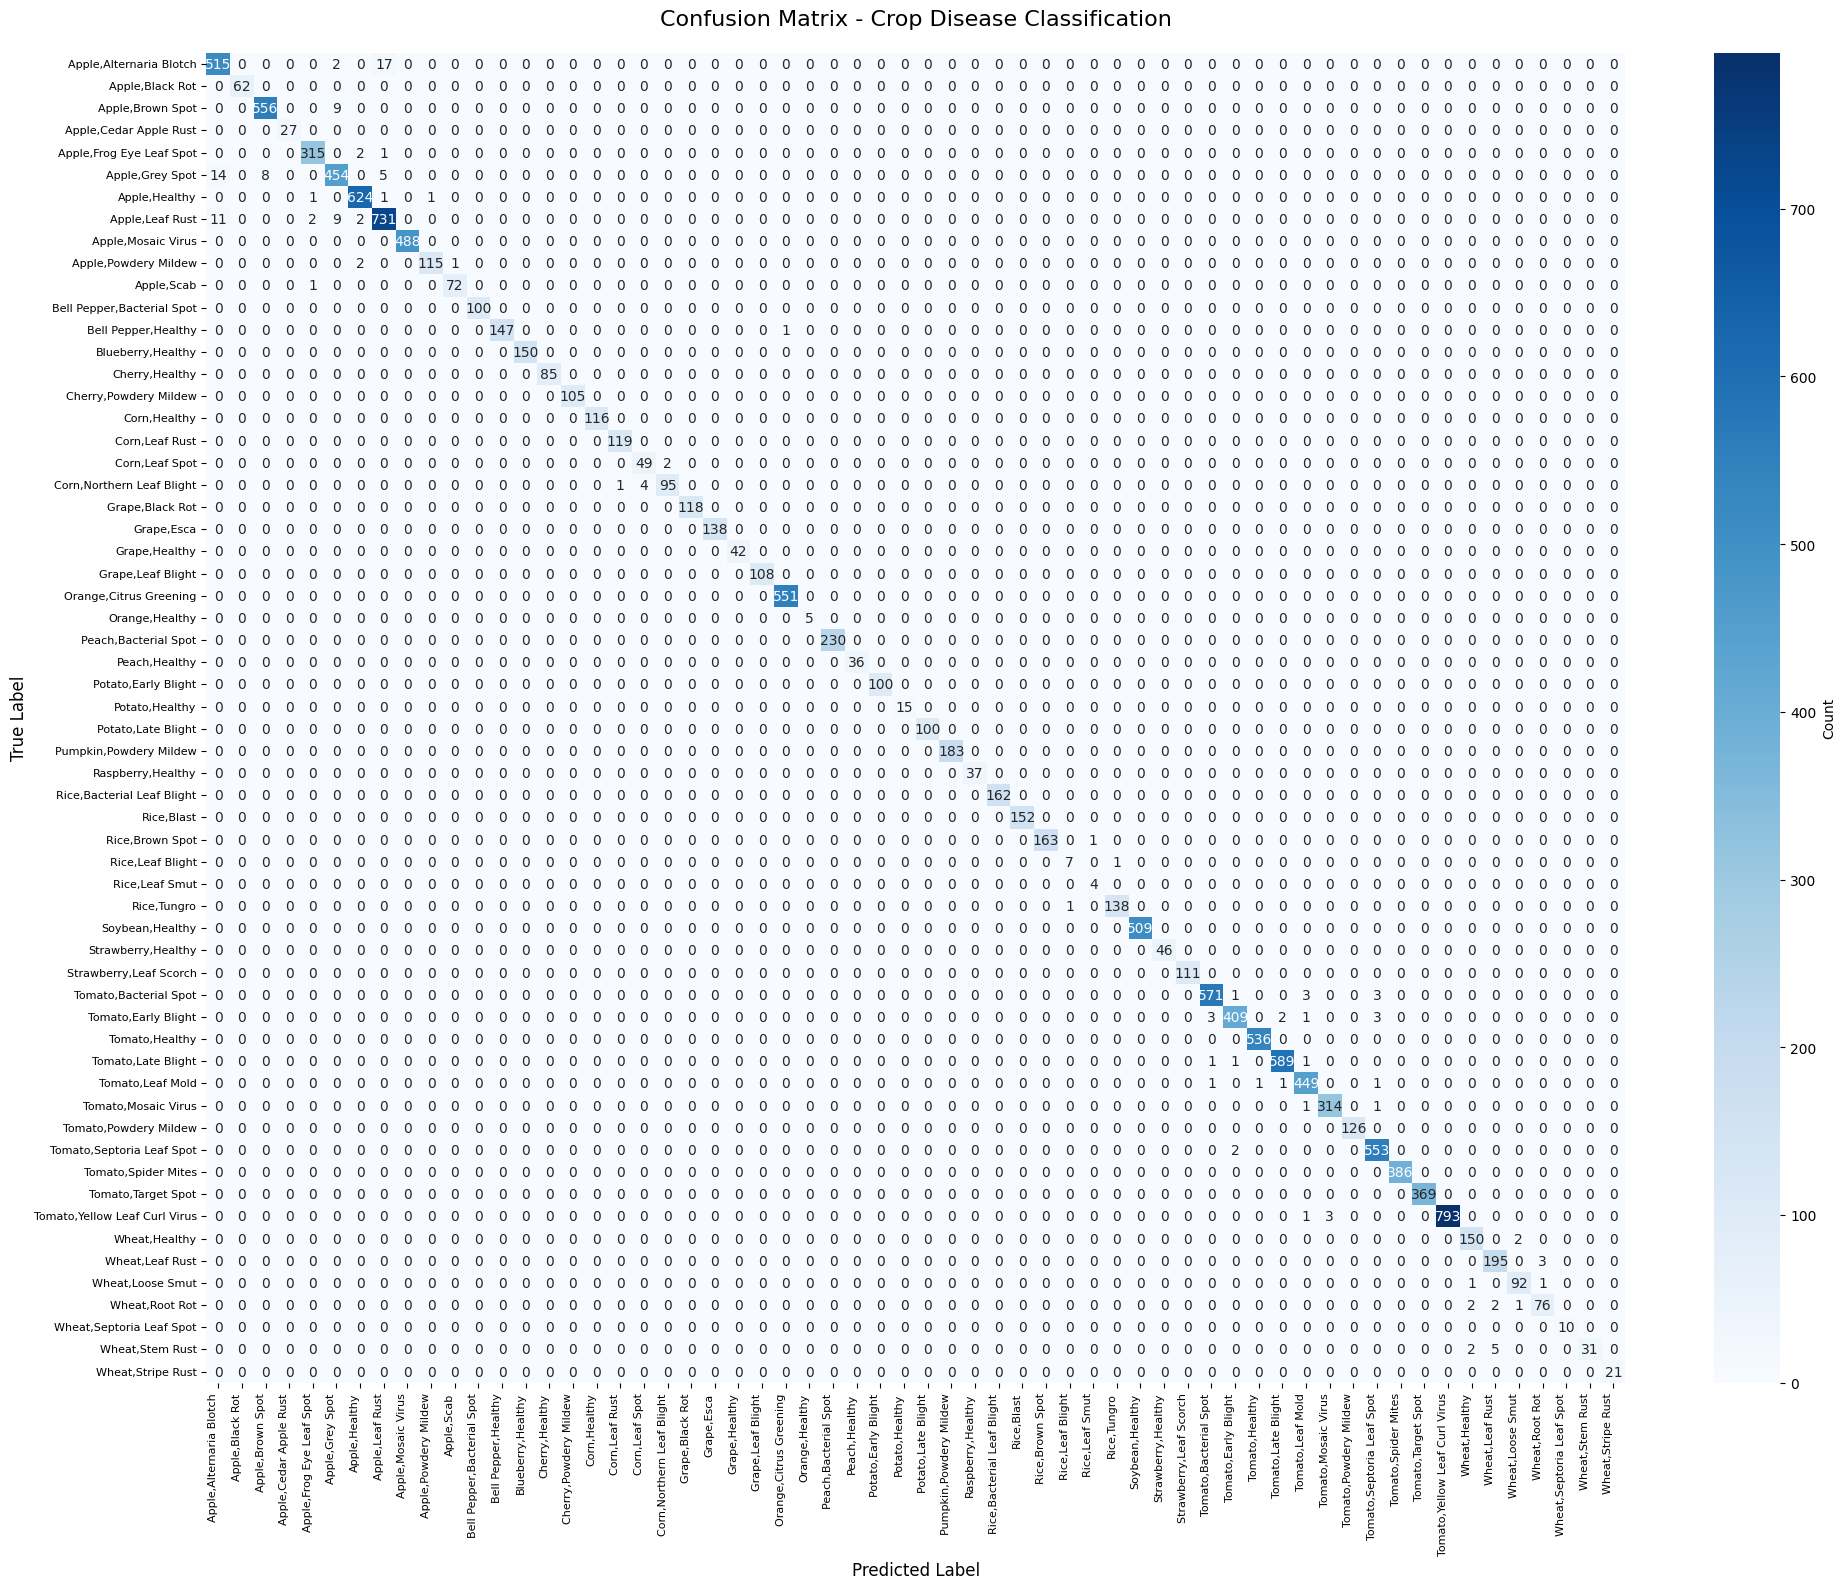

In [38]:
cm = confusion_matrix(y_true, y_pred, labels=list(range(len(unique_labels))))

plt.figure(figsize=(20, 16))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=unique_labels,
    yticklabels=unique_labels,
    cbar_kws={"label": "Count"},
)
plt.title("Confusion Matrix - Crop Disease Classification", fontsize=16, pad=20)
plt.ylabel("True Label", fontsize=12)
plt.xlabel("Predicted Label", fontsize=12)
plt.xticks(rotation=90, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

In [43]:
accuracy = np.trace(cm) / np.sum(cm)
print(accuracy)

0.9890510948905109
